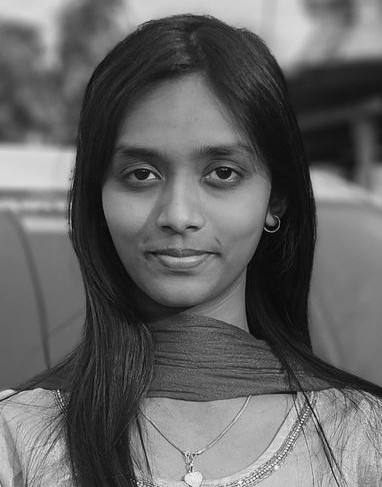

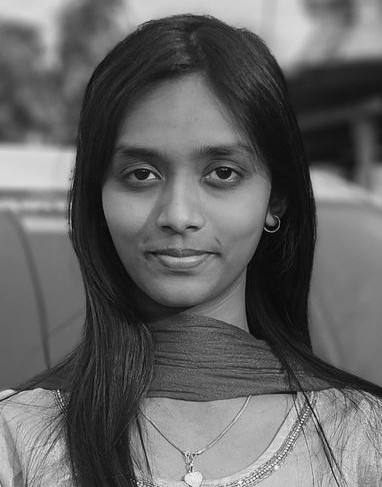

In [14]:
import cv2
import numpy as np

def mean_filter(image, kernel_size):
    # Pad the image to handle borders using zero-padding
    # This ensures that the filter can be applied to border pixels as well
    padded_image = cv2.copyMakeBorder(image,
                                      kernel_size//2,
                                      kernel_size//2,
                                      kernel_size//2,
                                      kernel_size//2,
                                      cv2.BORDER_CONSTANT)

    # Create an empty image to store the filtered result
    filtered_image = np.zeros_like(image)

    # Iterate over each pixel in the image
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            # Extract the local window centered at the current pixel
            window = padded_image[y:y+kernel_size, x:x+kernel_size]
            # Calculate the mean value of the window
            mean_value = np.mean(window)
            # Assign the mean value to the corresponding pixel in the filtered image
            filtered_image[y, x] = mean_value

    return filtered_image

# Load the image in grayscale mode
image = cv2.imread('/content/sample_data/my_image.jpeg', cv2.IMREAD_GRAYSCALE)

# Define the kernel size for the mean filter
kernel_size = 1

# Apply the mean filter to the image
filtered_image = mean_filter(image, kernel_size)

# Display the original and filtered images
from google.colab.patches import cv2_imshow

cv2_imshow(image)
cv2_imshow(filtered_image)

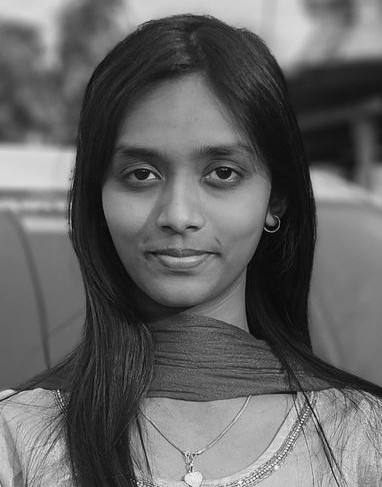

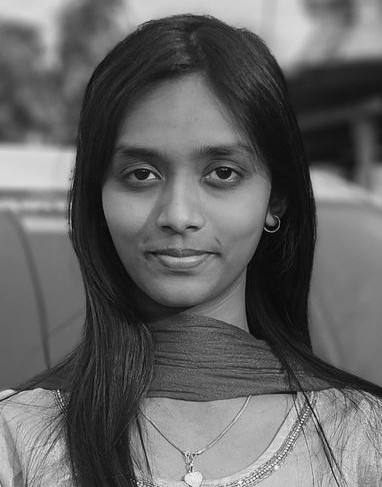

In [15]:
import cv2
import numpy as np

def sobel_filter(image):
 sobel_x_kernel = np.array([[-1, 0, 1],
                             [-2, 0, 2],
                             [-1, 0, 1]])

 sobel_y_kernel = np.array([[-1, -2, -1],
                             [0, 0, 0],
                             [1, 2, 1]])

 # Apply convolution with Sobel kernels
 sobel_x = cv2.filter2D(image, cv2.CV_64F, sobel_x_kernel)
 sobel_y = cv2.filter2D(image, cv2.CV_64F, sobel_y_kernel)

 # Calculate gradient magnitude
 gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

 # Normalize the gradient magnitude to the range [0, 255]
 normalized_gradient = cv2.normalize(gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

 return normalized_gradient

# Load the image in grayscale
image_path = '/content/sample_data/my_image.jpeg'  # Change this to your image path
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Apply Sobel filter
output_edge_image = sobel_filter(image)

# Display the original and edge-detected images (optional)
from google.colab.patches import cv2_imshow

cv2_imshow(image)
cv2_imshow(filtered_image)


Saving my_image.jpeg to my_image.jpeg


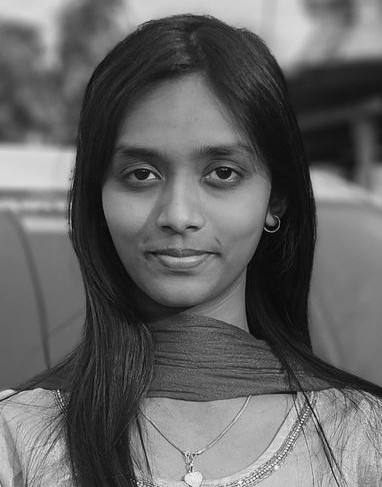

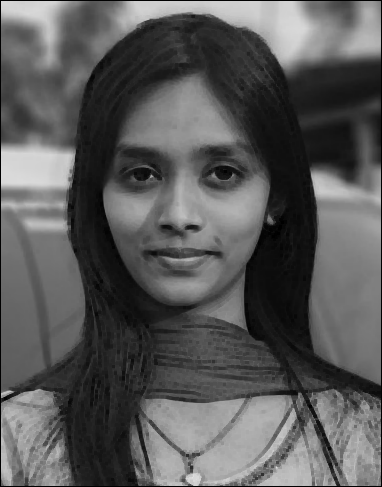

In [16]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
from google.colab import files

# Upload image
uploaded = files.upload()

def generate_kernel(size):
    return np.ones((size, size), dtype=np.uint8)

def erode(image, kernel):
    height, width = image.shape
    kernel_height, kernel_width = kernel.shape
    offset_y = kernel_height // 2
    offset_x = kernel_width // 2

    eroded_image = np.zeros_like(image)

    for y in range(offset_y, height - offset_y):
        for x in range(offset_x, width - offset_x):
            region = image[y - offset_y:y + offset_y + 1,
                           x - offset_x:x + offset_x + 1]
            eroded_image[y, x] = np.min(region * kernel)

    return eroded_image

# Load uploaded image
image = cv2.imread('my_image.jpeg', cv2.IMREAD_GRAYSCALE)

if image is None:
    print("❌ Image not loaded")
else:
    kernel = generate_kernel(3)
    eroded_image = erode(image, kernel)

    cv2_imshow(image)
    cv2_imshow(eroded_image)

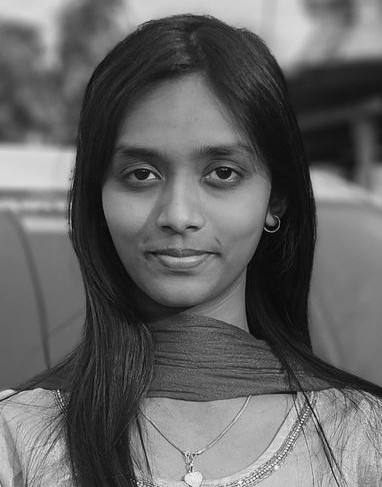

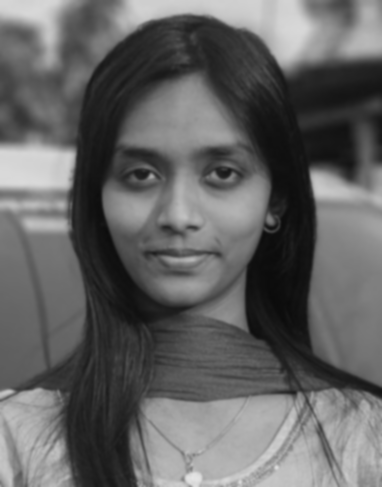

In [17]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import convolve

def gaussian_kernel(size, size_y=None):
   size = int(size)
   if not size_y:
       size_y = size
   else:
       size_y = int(size_y)
   x, y = np.mgrid[-size:size+1, -size_y:size_y+1]
   g = np.exp(-(x**2/float(size) + y**2/float(size_y)))
   return g / g.sum()

# Make the Gaussian kernel by calling the function
kernel_size = 3


gaussian_kernel_array = gaussian_kernel(kernel_size)

# Load a generic image in grayscale (replace 'lenna.jpeg' with the actual path)
image = cv2.imread('/content/sample_data/my_image.jpeg', cv2.IMREAD_GRAYSCALE)


# Apply Gaussian filter to the image
filtered_image = convolve(image, gaussian_kernel_array)

# Display the original and filtered images
# Display the original and filtered images
from google.colab.patches import cv2_imshow

cv2_imshow(image)
cv2_imshow(filtered_image)

Saving my_image.jpeg to my_image (1).jpeg


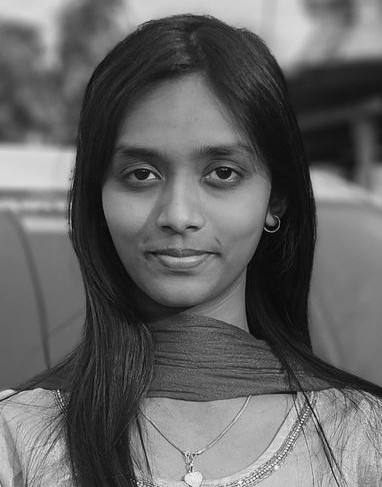

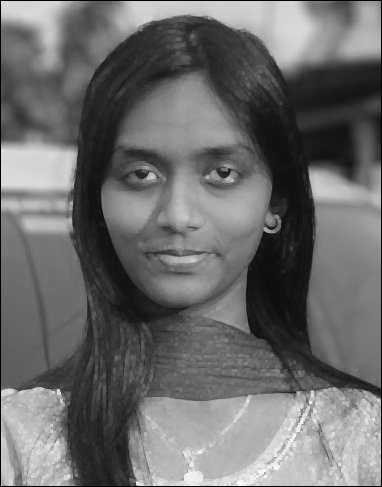

In [19]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
from google.colab import files

# Upload image
uploaded = files.upload()

def generate_kernel(size):
    return np.ones((size, size), dtype=np.uint8)

def dilate(image, kernel):
    height, width = image.shape
    k_h, k_w = kernel.shape
    offset_y = k_h // 2
    offset_x = k_w // 2

    dilated_image = np.zeros_like(image)

    for y in range(offset_y, height - offset_y):
        for x in range(offset_x, width - offset_x):
            region = image[y - offset_y:y + offset_y + 1,
                           x - offset_x:x + offset_x + 1]
            dilated_image[y, x] = np.max(region * kernel)

    return dilated_image

# Load image (after upload)
image = cv2.imread('my_image.jpeg', cv2.IMREAD_GRAYSCALE)

if image is None:
    print("❌ Image not loaded")
else:
    kernel = generate_kernel(3)
    dilated_image = dilate(image, kernel)

    cv2_imshow(image)
    cv2_imshow(dilated_image)

Saving my_image.jpeg to my_image (2).jpeg


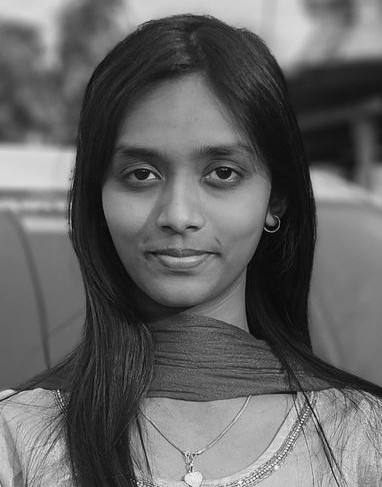

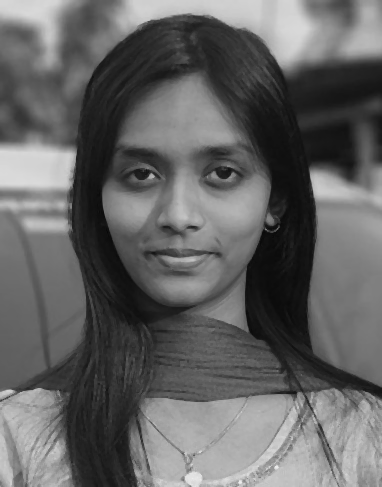

In [21]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
from google.colab import files

# Upload image
uploaded = files.upload()

def custom_median_filter(image, kernel_size):
    height, width = image.shape
    filtered_image = np.zeros_like(image)
    k = kernel_size // 2

    for i in range(height):
        for j in range(width):
            values = []
            for ki in range(-k, k + 1):
                for kj in range(-k, k + 1):
                    ni, nj = i + ki, j + kj
                    if 0 <= ni < height and 0 <= nj < width:
                        values.append(image[ni, nj])

            filtered_image[i, j] = np.median(values)

    return filtered_image

# Load image
image = cv2.imread('my_image.jpeg', cv2.IMREAD_GRAYSCALE)

if image is None:
    print("❌ Image not loaded")
else:
    kernel_size = 3
    filtered_image_custom = custom_median_filter(image, kernel_size)

    cv2_imshow(image)
    cv2_imshow(filtered_image_custom)

Saving my_image.jpeg to my_image (3).jpeg


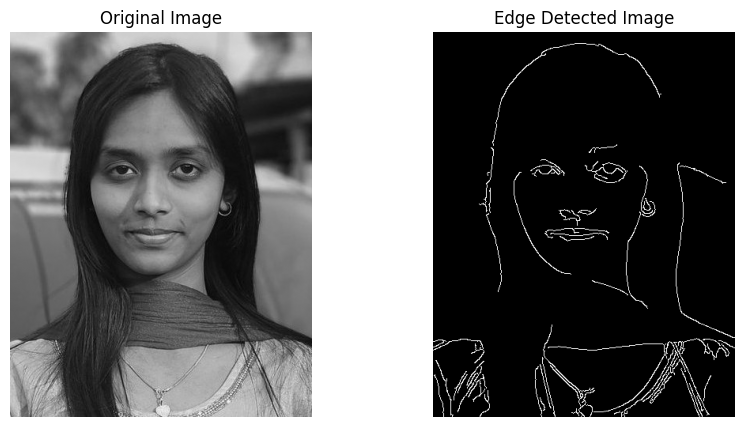

In [22]:
# Step 1: Import necessary libraries
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np

# Step 2: Upload an image
uploaded = files.upload()

# Step 3: Read the uploaded image
image_path = next(iter(uploaded))
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Step 4: Apply Gaussian Blur to reduce noise
blurred_image = cv2.GaussianBlur(image, (5, 5), 1.4)

# Step 5: Apply Canny edge detector
edges = cv2.Canny(blurred_image, 50, 150)

# Step 6: Display the original image and the edge-detected image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Edge Detected Image')
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()